<div style="border: 5px solid #003366; border-radius: 8px; padding: 20px;">

### **Course:** DSC630 — Predictive Analytics
### **Name:** Tim Hollis
### **Assignment:** Exercise 1.2
### **Date:** 03/20/2026

---

This notebook explores the Spotify Tracks Dataset sourced from Kaggle, containing audio features and metadata for tracks spanning 125 genres. Using Python, we perform exploratory data analysis and create visualizations to investigate two questions:

1. Is there a relationship between valence (musical happiness) and track popularity?
2. Do songs with higher energy tend to have higher popularity?

---

**Reference:**

Pandya, M. (2022). *Spotify Tracks Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

</div>

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

# Suppress warnings
warnings.filterwarnings('ignore')

# Suppress scientific notation and format numbers with commas
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_columns', 20)

# Global color palette: colorblind-safe
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#DAA520', '#C71585',
           '#6A5ACD', '#2E8B57', '#8B0000', '#556B2F', '#9932CC']
BLUE = '#4169E1'
PURPLE = '#4B0082'
GREEN = '#228B22'

# Set global plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load the dataset
df = pd.read_csv('spotify_tracks.csv')

print('✅ Libraries loaded and dataset ready!')
print(f'📦 Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns')
print(f'📋 Columns: {list(df.columns)}')

✅ Libraries loaded and dataset ready!
📦 Shape: 114,000 rows × 21 columns
📋 Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


### Section 1: Data Summary

In [2]:
# Preview the first three rows of relevant columns to confirm structure
print('🎵 Spotify Tracks Dataset — First 3 Rows:')
display(df[['track_name', 'artists', 'track_genre', 'popularity',
        'energy', 'valence', 'danceability']].head(3))

# Summary statistics for key audio features
print('\n📊 Summary Statistics for Key Audio Features:')
display(df[['popularity', 'energy', 'valence',
        'danceability', 'loudness']].describe().round(2))

# Check for missing values
print('\n🔍 Missing Values per Column:')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('✅ No missing values found!')
else:
    print(missing)

🎵 Spotify Tracks Dataset — First 3 Rows:


,track_name,artists,track_genre,popularity,energy,valence,danceability
0,Comedy,Gen Hoshino,acoustic,73,0.4610,0.7150,0.6760
1,Ghost - Acoustic,Ben Woodward,acoustic,55,0.1660,0.2670,0.4200
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,57,0.3590,0.1200,0.4380



📊 Summary Statistics for Key Audio Features:


,popularity,energy,valence,danceability,loudness
count,"114,000.0000","114,000.0000","114,000.0000","114,000.0000","114,000.0000"
mean,33.2400,0.6400,0.4700,0.5700,-8.2600
std,22.3100,0.2500,0.2600,0.1700,5.0300
min,0.0000,0.0000,0.0000,0.0000,-49.5300
25%,17.0000,0.4700,0.2600,0.4600,-10.0100
50%,35.0000,0.6800,0.4600,0.5800,-7.0000
75%,50.0000,0.8500,0.6800,0.7000,-5.0000
max,100.0000,1.0000,1.0000,0.9800,4.5300



🔍 Missing Values per Column:
artists       1
album_name    1
track_name    1
dtype: int64


<div style="border: 3px solid #003366; border-radius: 8px; padding: 15px;">

### Data Summary

The Spotify Tracks Dataset contains 114,000 tracks spanning 125 genres, with 21 columns capturing both metadata and audio features. The three missing values across artists, album_name, and track_name are negligible at this scale and will not affect analysis.

The average track popularity score is 33.24 out of 100, suggesting most tracks in this dataset are mid-tier in reach rather than mainstream hits. Energy averages 0.64, indicating the dataset leans toward moderately high-energy music. Valence, which measures musical positivity, averages 0.47 — sitting just below neutral, meaning the dataset trends slightly toward darker or more melancholic tones overall. These distributions set the stage for our two core questions: whether valence and energy each have a meaningful relationship with how popular a track becomes.

</div>

### Section 2: Histogram: Distribution of Energy Scores

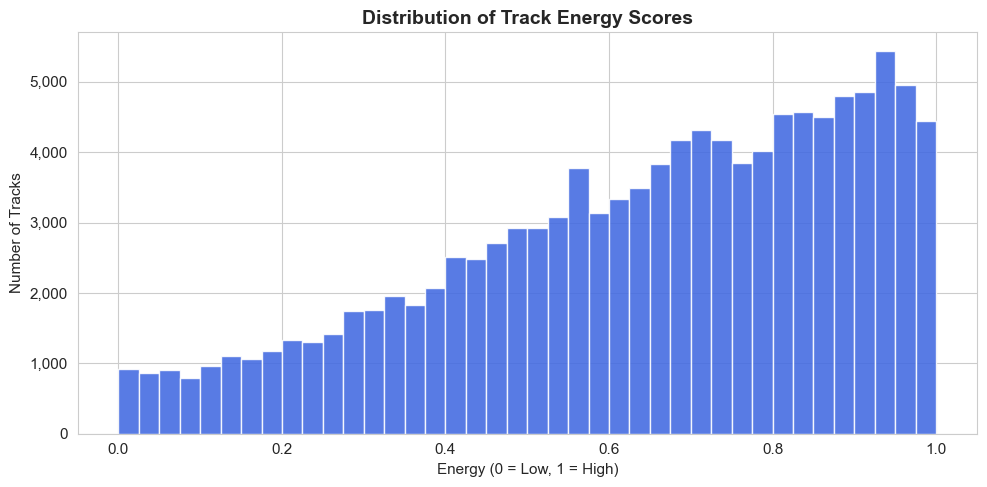

In [3]:
# Distribution of energy scores across all 114k tracks
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['energy'], bins=40, color=BLUE, edgecolor='white', alpha=0.88)

# Labels and formatting
ax.set_title(
    'Distribution of Track Energy Scores',
    fontsize=14,
    fontweight='bold')
ax.set_xlabel('Energy (0 = Low, 1 = High)')
ax.set_ylabel('Number of Tracks')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 15px;">

### Summary

The histogram reveals that energy scores across the dataset are heavily skewed toward the higher end of the scale, with the largest concentrations of tracks falling between 0.6 and 1.0. Very few tracks score below 0.2 in energy, suggesting that Spotify's catalog across genres tends to favor more energetic productions regardless of genre. This right-skewed distribution is important context for our second question, as it means we are largely examining how varying degrees of high energy relate to popularity rather than comparing extremes.

</div>

### Section 3: Boxplot: Popularity Distribution Across Genres

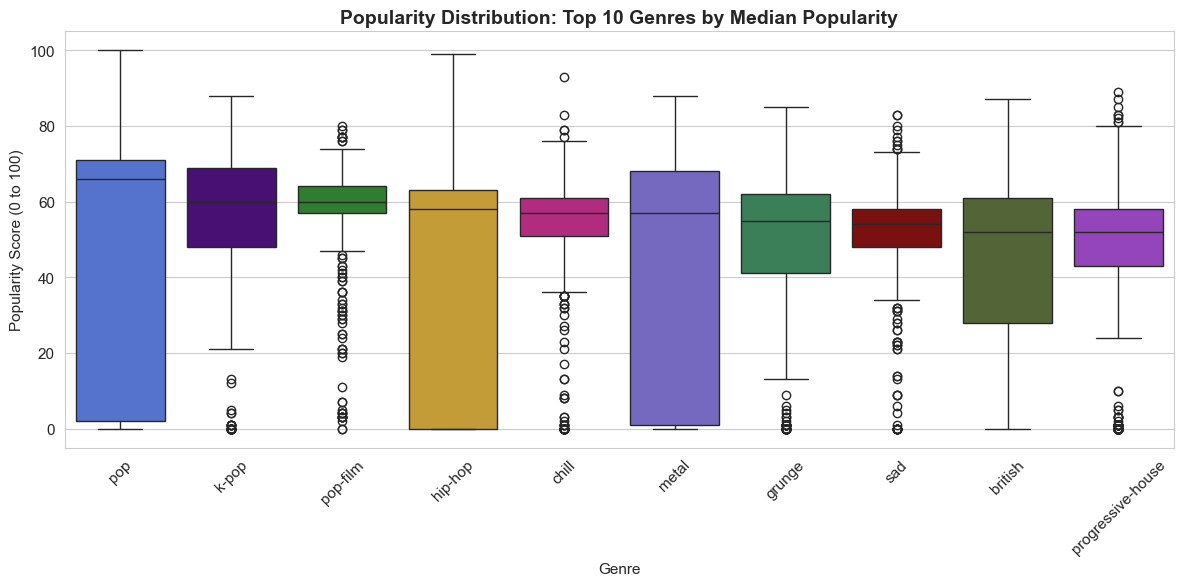

In [4]:
# Select 10 genres with the highest median popularity
top_genres = (
    df.groupby('track_genre')['popularity']
    .median()
    .nlargest(10)
    .index
)
df_top = df[df['track_genre'].isin(top_genres)]

# Plot popularity distribution across the top 10 genres by median popularity
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_top,
    x='track_genre',
    y='popularity',
    palette=PALETTE,
    order=top_genres,
    ax=ax
)

# Labels and formatting
ax.set_title(
    'Popularity Distribution: Top 10 Genres by Median Popularity',
    fontsize=14,
    fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Popularity Score (0 to 100)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 8px;">

### Summary

The boxplot reveals meaningful differences in popularity across the top 10 genres by median score. Pop leads with the highest median popularity and a wide interquartile range, reflecting both its mainstream dominance and the broad spectrum of pop tracks that range from obscure to globally recognized. K-pop follows closely with a moderately tight spread, suggesting more consistent popularity within that genre. Pop-film stands out for having the tightest interquartile range of any genre shown, indicating that soundtrack and film-related tracks tend to cluster around a predictable popularity level. Hip-hop and metal both show wide spreads similar to pop, reflecting high variability between tracks within those genres. Genres like chill, sad, and progressive-house show competitive median scores despite being more niche, suggesting that mood-based genre categories have found strong dedicated audiences on the platform.

</div>

### Section 4: Bivariate Plots: Valence and Energy vs. Popularity

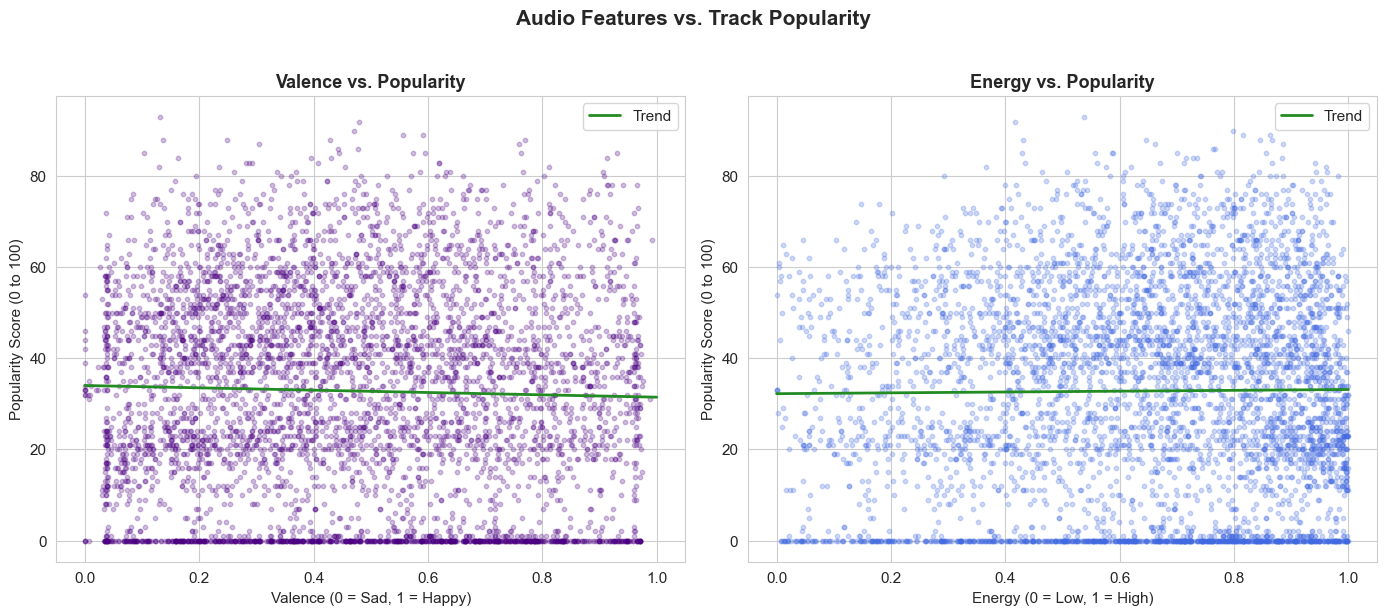

In [5]:
# Sample 5,000 tracks for cleaner scatter plots without overplotting
df_sample = df.sample(n=5000, random_state=42)

# Create side by side bivariate scatter plots for both questions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Valence vs Popularity
axes[0].scatter(
    df_sample['valence'],
    df_sample['popularity'],
    color=PURPLE,
    alpha=0.25,
    s=10
)
# Add a regression trend line
m, b = np.polyfit(df_sample['valence'], df_sample['popularity'], 1)
x_line = np.linspace(0, 1, 100)
axes[0].plot(x_line, m * x_line + b, color=GREEN, linewidth=2, label='Trend')
axes[0].set_title('Valence vs. Popularity', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Valence (0 = Sad, 1 = Happy)')
axes[0].set_ylabel('Popularity Score (0 to 100)')
axes[0].legend()

# Plot 2: Energy vs Popularity
axes[1].scatter(
    df_sample['energy'],
    df_sample['popularity'],
    color=BLUE,
    alpha=0.25,
    s=10
)
# Add a regression trend line
m2, b2 = np.polyfit(df_sample['energy'], df_sample['popularity'], 1)
axes[1].plot(x_line, m2 * x_line + b2, color=GREEN, linewidth=2, label='Trend')
axes[1].set_title('Energy vs. Popularity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Energy (0 = Low, 1 = High)')
axes[1].set_ylabel('Popularity Score (0 to 100)')
axes[1].legend()

plt.suptitle('Audio Features vs. Track Popularity',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 15px;">

### Summary

Both scatter plots reveal that neither valence nor energy has a strong linear relationship with track popularity. The trend lines in both plots are nearly flat, hovering around a popularity score of 30 to 35 regardless of where a track falls on either audio feature scale. This suggests that how happy or how energetic a song sounds does not reliably predict how popular it will become on Spotify. The wide vertical spread of points at every level of both features confirms that popularity is influenced by many factors beyond these audio characteristics alone, such as artist recognition, playlist placement, and marketing. These findings set up our additional visualization, where we take a closer look at the correlation structure across all major audio features together.

</div>

### Section 5: Additional Visualization: Audio Feature Correlation Heatmap

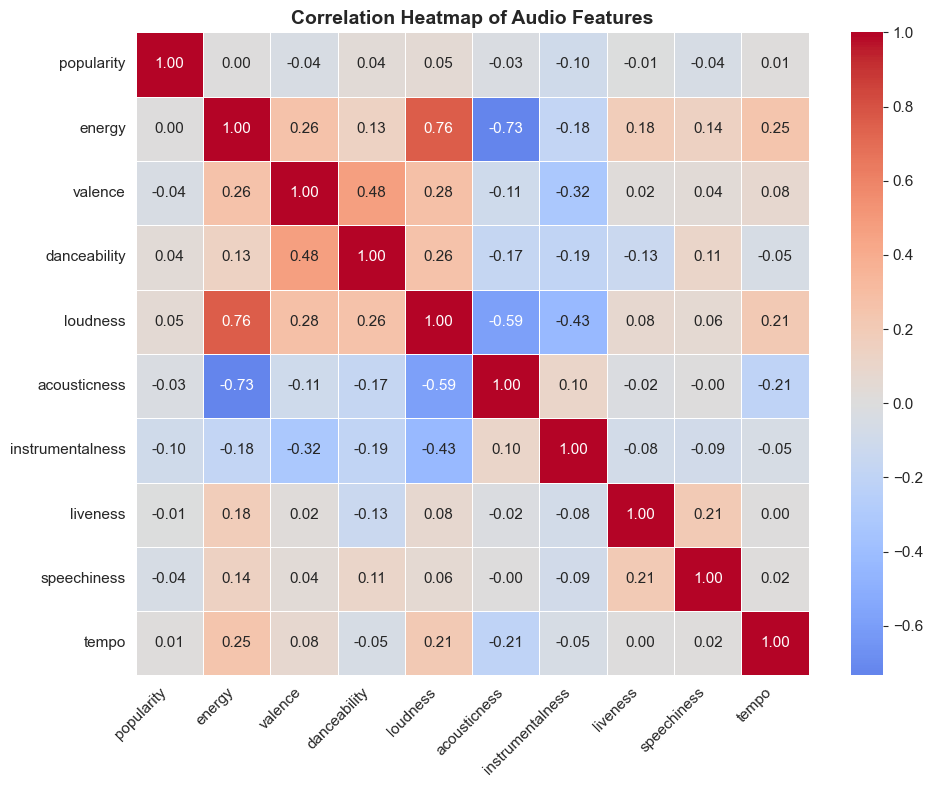

In [6]:
# Select only the numeric audio features for correlation analysis
audio_features = ['popularity', 'energy', 'valence', 'danceability',
                  'loudness', 'acousticness', 'instrumentalness',
                  'liveness', 'speechiness', 'tempo']

# Compute the correlation matrix
corr_matrix = df[audio_features].corr()

# Plot the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title(
    'Correlation Heatmap of Audio Features',
    fontsize=14,
    fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 15px;">

### Summary

The correlation heatmap confirms what the scatter plots suggested: popularity has near-zero correlation with every audio feature in the dataset, with the highest being loudness at just 0.05. This reinforces the conclusion that sonic characteristics alone are poor predictors of a track's commercial success on Spotify. The most notable relationships in the heatmap exist between other audio features rather than popularity itself. Energy and loudness share a strong positive correlation of 0.76, meaning louder tracks tend to also feel more energetic. Conversely, energy and acousticness show a strong negative correlation of -0.73, which makes intuitive sense as acoustic tracks are generally softer and less driven by electronic production. Valence and danceability also share a moderate positive correlation of 0.48, suggesting that happier sounding tracks tend to be more danceable. These inter-feature relationships provide useful context for understanding the structure of the dataset even if they do not directly explain popularity.

</div>

<div style="border: 3px solid #003366; border-radius: 8px; padding: 15px;">

### Section 6: Summary and Conclusion

This analysis explored two questions using the Spotify Tracks Dataset of 114,000 tracks spanning 125 genres: whether valence relates to track popularity, and whether energy relates to track popularity.

The histogram revealed that energy scores across the dataset skew heavily toward the higher end of the scale, with most tracks scoring between 0.6 and 1.0. The boxplot showed that genres like pop, k-pop, and hip-hop tend to produce the most popular tracks, while also exhibiting wide variability within their own genre. The bivariate scatter plots for both valence and energy against popularity produced nearly flat trend lines, indicating that neither audio feature has a meaningful linear relationship with how popular a track becomes. The correlation heatmap confirmed this finding, showing that popularity correlates at or near zero with every audio feature examined.

The conclusion drawn from these visualizations is that track popularity on Spotify is not driven by how happy or energetic a song sounds. Instead, popularity appears to be shaped by factors outside the audio signal itself, such as artist profile, genre audience size, playlist curation, and promotional reach. The strongest relationships in the data exist between audio features themselves, particularly the energy-loudness and energy-acousticness pairings, rather than between any feature and popularity. For future analysis, incorporating artist follower counts, playlist inclusion data, or release date metadata would likely produce far stronger predictors of track popularity than audio features alone.

</div>

<div style="border: 5px solid #228B22; border-radius: 8px; padding: 10px;">
    
## Overall Reflection

This assignment served as a valuable refresher on the end-to-end data analysis and visualization workflow using Python. The open-ended nature of the assignment, choosing your own dataset and forming your own questions, made it feel more like real exploratory work than a guided exercise. Having to identify at least two questions before touching any visuals forced a more intentional approach to the analysis, since every chart needed to actually serve a purpose rather than just describe the data. Working through the required visualization types in sequence, from the histogram to the boxplot to the bivariate plot and beyond, reinforced how each chart type answers a different kind of question. The histogram reveals distribution and shape, the boxplot surfaces spread and outliers across categories, and the bivariate plot begins to explore relationships between variables. Bringing it all together in a written conclusion was a good reminder that visuals alone are not enough... the analytical narrative is what turns charts into insights.

## Straightforward Portions

- Identifying a dataset of interest from sources like Kaggle or UCI and loading it into Python for initial inspection.
- Generating summary statistics to understand the shape and scale of the data before forming questions.
- Building the histogram and boxplot, which have straightforward syntax and map cleanly to common data questions.

## More Challenging Portions

- Formulating two questions that were specific enough to be answerable visually but broad enough to be genuinely interesting.
- Choosing the right variables and groupings for the bivariate plot, and deciding whether the relationship found was meaningful or just noise.
- Writing a conclusion that honestly interpreted what the visualizations showed, especially when the results were less clear-cut than expected.
- Selecting an additional visualization that added something new rather than just restating what earlier charts already showed.

</div>